## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Amelia Chen

**Date:** 9/30/2026

### Q1 Responses

1. **What is the difference between regression and classification?**

Regression and classification are both types of algorithms that are used to make predictions about data. Regression is used to make predictions about numerical data, while classification is used to make predictions about categorical data.

For kNN, to use regression to make a prediction about the $\hat{y}$ of a new observation $\hat{x}$, we must first compute the distance between $\hat{x}$ and every $x_i$. With the distances calculated, we selected the nearest $k$ neighbors, which have outcomes $y^*_1…y^*_k$. The final value of $\hat{y}$ is the average of our selected outcomes, or $\frac{1}{k} \sum_{j=1}^k y^*_j$.

For kNN classification, we start with the same step of computing the distance between our new observation $\hat{x}$ and all other $x_i$, then selecting the $k$ nearest neighbors. From the selected $k$, we calculate the proportion of each category by dividing its count by $k$. The class with the highest proportion is the predicted $\hat{y}$ value.

2. **What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a method of representing the accuracy of predictions. The rows of the table represent the actual classes, and the columns of the table represent the predicted classes. In this way, the diagonals of the table represent when the actual classes intersect/match the predicted classes, reflecting the accuracy of the model’s performance. The off-diagonal cells of the table represent when the actual classes did not match the model’s prediction. Being able to visualize the class-by-class accuracy of the model allows us to understand not just the overall accuracy/inaccuracy, but also if the model performs better on some features compared to others.

3. **What does the SSE quantify about a particular model?**

The SSE is a metric for understanding the accuracy of a model. The formula for SSE takes each of the residuals, squares them, and adds them together. Each residual quantifies the prediction error: how far away the prediction was from the actual value. A residual of 0 means the prediction was the same as the actual; a residual greater than 0 means the model underpredicted; and a residual less then 0 means the model overpredicted. In SSE, we want to square all of the residuals so that any negative residuals don’t cancel out the positive residuals. Next, we add all of the residuals together, resulting in a value that represents the overall error of the model. In the context of kNN, calculating the SSE is useful because we can test out different $k$ values and figure out which one results in the lowest error/SSE.

4. **What are overfitting and underfitting?**

When we train a model on training data to prepare it to be used for making predictions, that is described as “fitting” the model. Depending on how the model was trained, our actual test/validation results may point to the model being either overfitted or underfitted. In the context of kNN, the general pattern is that as $k$ increases, the model averages more observations to make it’s predictions, gradually leading to less and less variation.

Overfitting occurs when $k$ remains too small: the model has too few observations to draw from, so the pattern that the model is intended to capture is not yet visible. Noisy data points result in high variation in predictions. On the other hand, underfitting occurs when $k$ becomes too big: the model starts to average too many observations, and any meaningful patterns get lost. The result is that the model provides the same, dominant prediction every single time, even for very different $x$ points.

5. **Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

It is necessary to split the data into training and testing sets to optimize the model’s ability to generalize. We want to be able to train the model on a small subset of the data and apply the model to any data that is a similar form. If we were to train and test the model on the same subset of data, the model could potentially learn the data perfectly in training, then when we test it we will find that it has 100% accuracy. This is misleading, as if we were to apply the model to some new data that it was unfamiliar with, we may find that it performs very poorly. The model didn’t actually learn to recognize general patterns, it only learned the patterns specific to the training data. Similarly, we want to choose our $k$ value based off of the accuracy/SSE of the validation data, not the training data. The validation data is intended to provide insights about the model’s performance on generalized data, so lower error in validation indicates, generally, a more accurate model.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class label as a prediction is a simpler approach that provides a concrete classification immediately. However, it strips away the context of the prediction. With the probability distribution approach, we are able to see exactly how many neighbors belonged to each class. This may be useful when trying to decide $k$ values, as we want to decide what value of $k$ can overcome noise while still capturing the desired pattern. The drawback of the probability distribution is that it may require additional processing to determine what the actual classification should be. 

As an example, let’s say we have selected $k$=5:
- Case 1: point $x$’s 5 neighbors are SUV
- Case 2: point $y$ has 3 neighbors that are SUV, 2 neighbors that are car

If we only received the prediction as output, in both cases we would have simply accepted that points $x$ and $y$ are likely SUV’s. However, if we had seen the probability distribution, we would have been able to see clearly that point $x$ is likely an SUV, and we may have considered the possibility that point $y$ is a car that has more neighbors that are SUV’s due to noise/low $k$ value.

(338, 4) 

voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


<Figure size 640x480 with 0 Axes>

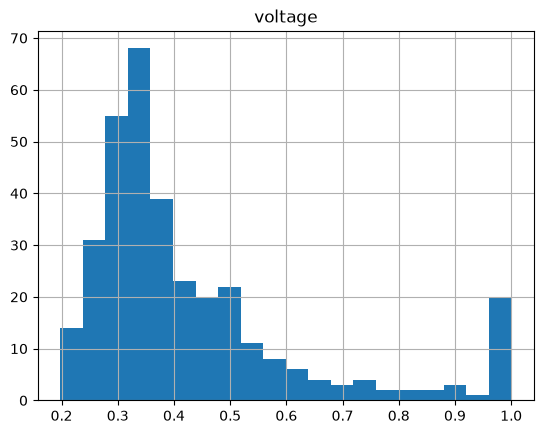

,mean,median,mode,min,max,Q1,Q3
0,0.431,0.36,1.0,0.198,1.0,0.31,0.483


<Figure size 640x480 with 0 Axes>

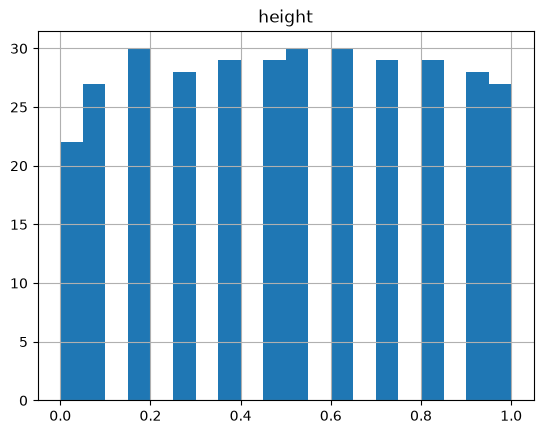

,mean,median,mode,min,max,Q1,Q3
0,0.509,0.545,0.182,0.0,1.0,0.273,0.727


<Figure size 640x480 with 0 Axes>

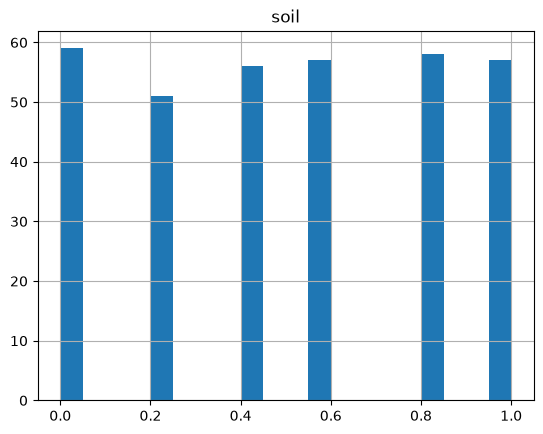

,mean,median,mode,min,max,Q1,Q3
0,0.504,0.6,0.0,0.0,1.0,0.2,0.8


<Figure size 640x480 with 0 Axes>

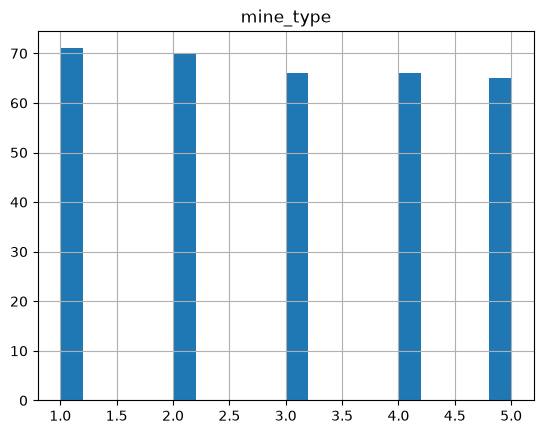

,mean,median,mode,min,max,Q1,Q3
0,2.953,3.0,1,1,5,2.0,4.0


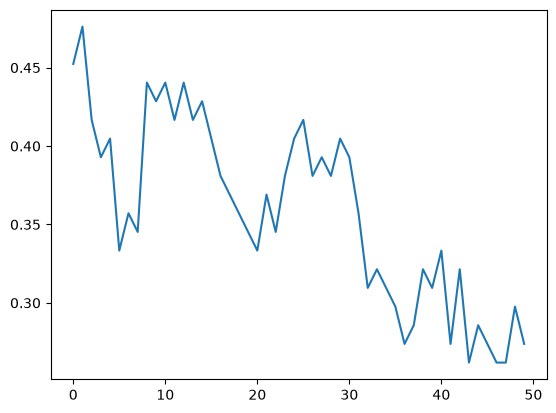

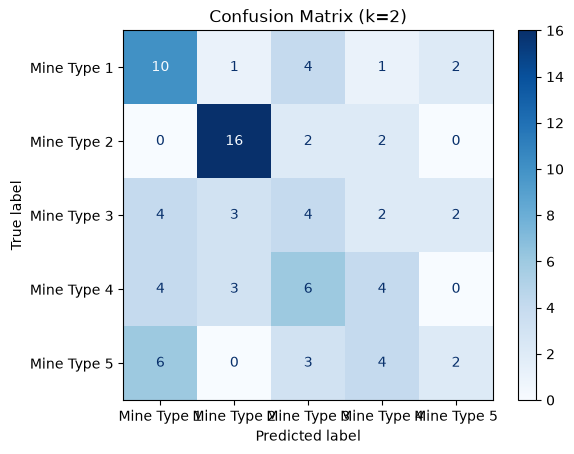

accuracy:  0.4235294117647059


"\nNotice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. \nPlease explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.\n\nGiven the patterns in the errors the model makes, I would adivse someone who is using this predictive model in practice not to trust\nclassifications of Mine Types 3, 4, and 5, as these have high misclassification rates. For Mine Types 2 and 1, I would recommend someone\nto look at the probability distributions of classification predictions, as the additional context may be useful in making informed predictions\nabout classifications.\n"

In [12]:
# Sources:
# https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/
# https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

########## ========== Q2.1 ========== ##########
# Load the data. Perform some EDA, summarizing the target label and the features.
filepath = 'data/land_mines.csv'
df = pd.read_csv(filepath, low_memory=False)

print(df.shape, '\n')   # output: (338, 4)
print(df.dtypes, '\n') 
print(df.head())
print(df.info())        # output: all 4 columns have 338 non-nulls = no missing values

plt.figure()
df.hist(column="voltage", bins=20)  # create a histogram for the voltage column
plt.savefig("voltage_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the voltage variable with summary statistics
    "mean": [df["voltage"].mean()],
    "median": [df["voltage"].median()],
    "mode": [df["voltage"].mode().iloc[0]],
    "min" : df["voltage"].min(),
    "max": df["voltage"].max(),
    "Q1": [df["voltage"].quantile(0.25)],
    "Q3": [df["voltage"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode   min	    max	    Q1	    Q3
0.431	0.36	1.0	   0.198	1.0	   0.31	   0.483

Most skewed histogram, steep increase from around 0.2 to a peak around 0.35.
Then drops steeply again until around 0.45, then continues to decrease slowly.
Another sharp peak at 1.0.
'''

plt.figure()
df.hist(column="height", bins=20)  # create a histogram for the height column
plt.savefig("height_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the height variable with summary statistics
    "mean": [df["height"].mean()],
    "median": [df["height"].median()],
    "mode": [df["height"].mode().iloc[0]],
    "min" : df["height"].min(),
    "max": df["height"].max(),
    "Q1": [df["height"].quantile(0.25)],
    "Q3": [df["height"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	 Q1	     Q3
0.509	0.545	0.182	0.0	   1.0	 0.273	 0.727

Height ranges from 0.0-1.0, histogram has a slight peak in the middle.
Overall still relatively equally dustributed
'''

plt.figure()
df.hist(column="soil", bins=20)  # create a histogram for the soil column
plt.savefig("soil_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the soil variable with summary statistics
    "mean": [df["soil"].mean()],
    "median": [df["soil"].median()],
    "mode": [df["soil"].mode().iloc[0]],
    "min" : df["soil"].min(),
    "max": df["soil"].max(),
    "Q1": [df["soil"].quantile(0.25)],
    "Q3": [df["soil"].quantile(0.75)],
})
display(summary.round(3))

'''

mean	median	mode	min	   max	  Q1	Q3
0.504	0.6	     0.0	0.0	   1.0	  0.2	0.8

Soil values appear to be either 0.0, 0.2, 0.4, 0.6, 0.8, and 1.0.
Relatively evenly distributed.
'''

plt.figure()
df.hist(column="mine_type", bins=20)  # create a histogram for the mine_type column
plt.savefig("mine_type_histogram.png")
plt.show()

summary = pd.DataFrame({    # describing the mine_type variable with summary statistics
    "mean": [df["mine_type"].mean()],
    "median": [df["mine_type"].median()],
    "mode": [df["mine_type"].mode().iloc[0]],
    "min" : df["mine_type"].min(),
    "max": df["mine_type"].max(),
    "Q1": [df["mine_type"].quantile(0.25)],
    "Q3": [df["mine_type"].quantile(0.75)],
})
display(summary.round(3))

'''
mean	median	mode	min	   max	   Q1	   Q3
2.953	3.0	     1	     1	    5	   2.0	   4.0

Observed that the 5 mine types are relatively evenly distributed.
'''


########## ========== Q2.2 ========== ##########
# Split the sample 50/50 into training and test/validation sets.
# (The smaller the data are, the more equal the split should be, in my experience:
# Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

# first split into 50/50 then split latter 50 into 50/50
# result: 50% train, 25% validate, 25% test
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_test_raw,
    eval_y_train,
    eval_y_valid_test,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

(
    eval_X_valid_raw,
    classification_X_test_raw,
    eval_y_valid,
    classification_y_test,
) = train_test_split(
    eval_X_valid_test_raw, eval_y_valid_test, test_size=0.50, random_state=65
)

# fit the scalar on the training data, then transform both the training and validation data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


########## ========== Q2.3 ========== ##########
# Build a $k$-NN classifier. Explain how you select k.

# test out fitting the model on a range of k values
# for each k, create a classifier and fit it with that k value.
# predict results on the validation dataset and calculate the accuracy score
# choose the highest accuracy as eval_k_star
eval_ks = np.arange(1, 51)
eval_valid_accuracy = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_valid_accuracy.append(accuracy_score(eval_y_valid, eval_valid_hat))
eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)])

# show the k vs validation accuracy scores plot
k_plot = np.array(eval_valid_accuracy)
plt.plot(k_plot)
plt.show()

# fit the regressor on the best k value
classification_k = eval_k_star
classification_model = KNeighborsClassifier(n_neighbors = classification_k).fit(
    eval_X_train_scaled, eval_y_train
)


########## ========== Q2.4 ========== ##########
# Print a confusion table for the optimal model, comparing predicted and actual class label on the test set.

# predict on the test data
classification_X_test_scaled = eval_scaler.transform(classification_X_test_raw)
y_pred = classification_model.predict(classification_X_test_scaled)

# create the confusion matrix
cm = confusion_matrix(classification_y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mine Type 1", "Mine Type 2", "Mine Type 3", "Mine Type 4", "Mine Type 5"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={classification_k})")
plt.grid(False)
plt.show()

print("accuracy: ", accuracy_score(classification_y_test, y_pred))

'''
How accurate is it? Where is performance more or less accurate?

The overall accuracy of the model is around 0.424. Based on the confusion matrix, we observe that the model makes the most accurate
predictions for Mine Type 2 with 16 accurate predictions (80.00% class accuracy), followed by Mine Type 1 with 10 accurate predictions 
(55.56% class accuracy). For Mine Types 3 and 4, the model only predicts 4 classes correctly (26.67% and 23.53% class accuracy, respectively).
For Mine Type 5, the model only predicts 2 classes correctly (13.33% class accuracy). The model often mistakes Mine Type 5 for Mine type 1, 
as well as Mine Type 4 for Mine Type 3 (6 misclassifications each). All other off-diagonal cells have misclassifications ranging from 0-4.
'''

########## ========== Q2.5 ========== ##########
'''
Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. 
Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Given the patterns in the errors the model makes, I would adivse someone who is using this predictive model in practice not to trust
classifications of Mine Types 3, 4, and 5, as these have high misclassification rates. For Mine Types 2 and 1, I would recommend someone
to look at the probability distributions of classification predictions, as the additional context may be useful in making informed predictions
about classifications.
'''


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]